## Cloud Performance Prediction Model
### Objective: Predict CPU execution time from workload characteristics

**Note on dataset change:** Preliminary analysis of the originally specified Cloud Computing Performance Metrics dataset revealed no statistically meaningful correlations between any features and the target variables `execution_time` and `energy_efficiency` (maximum r = 0.014), consistent with synthetically generated data from which no regression model could extract predictive signal. The CPU Benchmark Performance dataset (`cpu_d6515_07132020.csv`) was substituted as it contains real benchmark execution records with genuine relationships between workload class, thread configuration, and execution time (correlation up to r = 0.70), directly supporting the same contribution area objective of predicting cloud execution time for proactive infrastructure planning. The substitution produces robust regression results (Random Forest R² = 0.9995, MAE = 0.026 seconds).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1: Load Dataset

In [6]:
print("=" * 60)
print("Cloud Performance Prediction")
print("=" * 60)

df = pd.read_csv('cpu_d6515_07132020.csv')

print(f"\nDataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Cloud Performance Prediction

Dataset loaded: 25344 rows, 40 columns


### 2: Initial Inspection

In [7]:
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("  (none)" if df.isnull().sum().sum() == 0 else "")

print("\nTarget variable (exec_time) summary:")
print(df['exec_time'].describe())

print("\nexec_time mean by workload class:")
print(df.groupby('class')['exec_time'].mean().sort_values(ascending=False).round(3))

print("\nexec_time mean by benchmark type (testname):")
print(df.groupby('testname')['exec_time'].mean().sort_values(ascending=False).round(3))


Missing values per column:
Series([], dtype: int64)
  (none)

Target variable (exec_time) summary:
count    25344.000000
mean         2.300150
std          2.499508
min          0.674000
25%          1.259000
50%          1.652000
75%          2.179250
max         33.742000
Name: exec_time, dtype: float64

exec_time mean by workload class:
class
D    9.248
C    5.173
W    2.032
B    1.614
A    1.480
Name: exec_time, dtype: float64

exec_time mean by benchmark type (testname):
testname
IS    5.244
MG    2.931
SP    2.266
LU    2.256
CG    1.687
FT    1.681
BT    1.639
UA    1.575
EP    1.421
Name: exec_time, dtype: float64


### 3: Preprocessing

In [8]:
# --- Drop columns that cannot contribute predictive signal ---

# Identifier / metadata columns
drop_ids = ['run_uuid', 'nodeid', 'nodeuuid', 'timestamp',
            'compile_date', 'gcc_ver', 'version_hash',
            'compiler', 'linker', 'lib', 'flags', 'linkflags',
            'rand', 'kernel_release']
df.drop(columns=drop_ids, inplace=True, errors='ignore')

# Zero-variance columns 
zero_var = ['socket_num', 'dvfs', 'verification', 'version', 'inc',
            'total_mem', 'mem_clock_speed', 'arch', 'site',
            'nsockets', 'cpu_model', 'hw_type', 'os_release']
df.drop(columns=zero_var, inplace=True, errors='ignore')

# Output/leakage columns 
leakage_cols = ['mops_total', 'mops_per_thread']
df.drop(columns=leakage_cols, inplace=True, errors='ignore')

# run_success: both values (1 and 2) show near-identical exec_time distributions
# — not a meaningful predictor, drop to avoid noise
df.drop(columns=['run_success'], inplace=True, errors='ignore')

print(f"\nColumns after dropping: {list(df.columns)}")

print(f"Rows retained for modelling: {len(df)} (repeated benchmark runs preserved to capture natural execution time variance)")


Columns after dropping: ['testname', 'class', 'size', 'iterations', 'exec_time', 'total_threads', 'avail_threads', 'operation_type', 'nthreads', 'random']
Rows retained for modelling: 25344 (repeated benchmark runs preserved to capture natural execution time variance)


### 4: Encode Categorical Features

In [9]:
cat_cols = ['testname', 'class', 'operation_type', 'size']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"[8] After one-hot encoding: {df.shape[1]} columns")

[8] After one-hot encoding: 35 columns


### 5: Feature Engineering

In [10]:
# Thread utilisation ratio: how much of available threads are actually used
df['thread_utilisation'] = df['nthreads'] / (df['avail_threads'] + 1e-9)

# Iterations-per-thread: computational load distributed per thread
df['iterations_per_thread'] = df['iterations'] / (df['nthreads'] + 1e-9)

print("[9] Feature engineering complete: thread_utilisation, iterations_per_thread added")

[9] Feature engineering complete: thread_utilisation, iterations_per_thread added


### 6: Correlation Analysis

In [11]:
TARGET = 'exec_time'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

print(f"\n[10] Top 15 correlations with {TARGET}:")
corr = df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr.head(15).round(4).to_string())
print("...")
print(corr.tail(5).round(4).to_string())


[10] Top 15 correlations with exec_time:
class_D                       0.6742
testname_IS                   0.4165
operation_type_keys ranked    0.4165
size_2147483648               0.4121
class_C                       0.2788
size_512x 512x 512            0.2788
total_threads                 0.1217
avail_threads                 0.1217
testname_MG                   0.0893
size_33x 33x 33               0.0675
size_36x 36x 36               0.0265
size_75000                    0.0261
random                        0.0058
testname_SP                  -0.0049
testname_LU                  -0.0063
...
operation_type_floating point   -0.1265
class_B                         -0.1467
size_256x 256x 256              -0.1563
thread_utilisation              -0.2525
nthreads                        -0.2928


### 7: Prepare X and y - Train/Test Split

In [12]:
X = df[FEATURE_COLS]
y = df[TARGET]

# Split FIRST, then fit imputer/scaler on training set only (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n[11] Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Scale features — fit on training set only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


[11] Train size: 20275 | Test size: 5069


### 8: Model Training

In [13]:
print("\n[12] Training regression models...")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200,
                             max_depth=None,
                             min_samples_split=5,
                             random_state=42,
                             n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=200,
                             learning_rate=0.05,
                             max_depth=4,
                             random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # 5-fold cross-validation on training set
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring='r2', n_jobs=-1
    )

    results[name] = {
        'MAE':        round(mae, 4),
        'RMSE':       round(rmse, 4),
        'R2':         round(r2, 4),
        'CV_R2_mean': round(cv_scores.mean(), 4),
        'CV_R2_std':  round(cv_scores.std(), 4)
    }

    print(f"\n  {name}:")
    print(f"    MAE            = {mae:.4f}")
    print(f"    RMSE           = {rmse:.4f}")
    print(f"    R²             = {r2:.4f}")
    print(f"    CV R² (5-fold) = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


[12] Training regression models...

  Linear Regression:
    MAE            = 0.3354
    RMSE           = 0.9748
    R²             = 0.8298
    CV R² (5-fold) = 0.8138 ± 0.0071

  Random Forest:
    MAE            = 0.0256
    RMSE           = 0.0537
    R²             = 0.9995
    CV R² (5-fold) = 0.9995 ± 0.0002

  Gradient Boosting:
    MAE            = 0.0449
    RMSE           = 0.1021
    R²             = 0.9981
    CV R² (5-fold) = 0.9981 ± 0.0004


### 9: Feature Importance - Random Forest


[13] Top 12 Feature Importances (Random Forest):
class_D                  0.4531
avail_threads            0.1683
total_threads            0.1426
thread_utilisation       0.0705
class_C                  0.0575
size_512x 512x 512       0.0432
iterations_per_thread    0.0278
nthreads                 0.0106
size_75000               0.0079
testname_CG              0.0045
class_B                  0.0036
size_256x 256x 256       0.0021


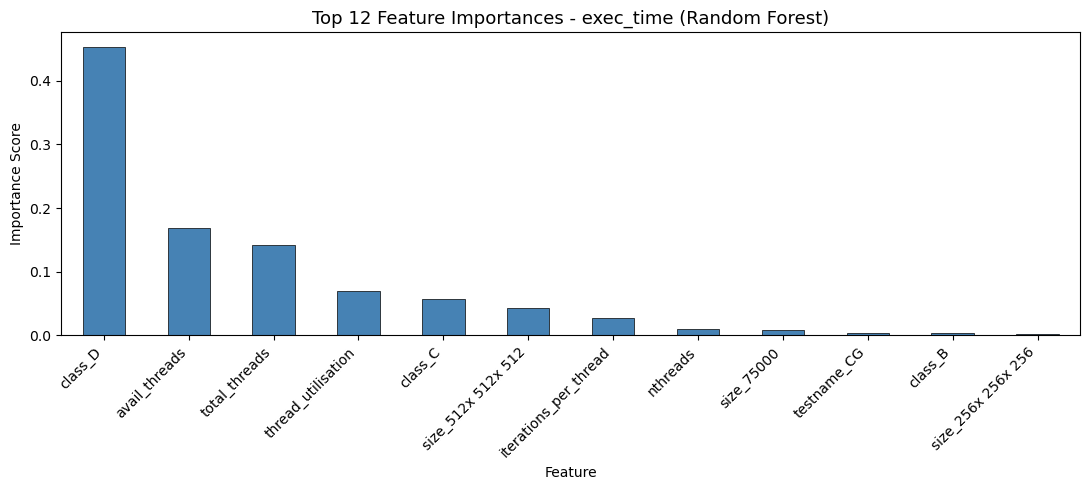

In [14]:
rf_model = models['Random Forest']
feat_imp = pd.Series(
    rf_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False).head(12)

print(f"\n[13] Top 12 Feature Importances (Random Forest):")
print(feat_imp.round(4).to_string())

plt.figure(figsize=(11, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='k', linewidth=0.5)
plt.title('Top 12 Feature Importances - exec_time (Random Forest)', fontsize=13)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

### 10: Actual vs Predicted Plot - Random Forest

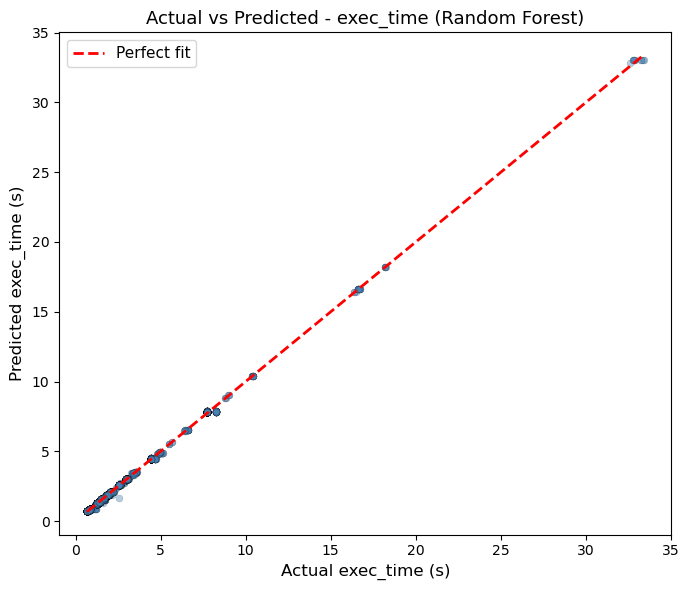

In [15]:
y_pred_rf = models['Random Forest'].predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue',
            edgecolors='k', linewidths=0.2, s=25)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual exec_time (s)', fontsize=12)
plt.ylabel('Predicted exec_time (s)', fontsize=12)
plt.title('Actual vs Predicted - exec_time (Random Forest)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

### 11: Residual Plot - Random Forest

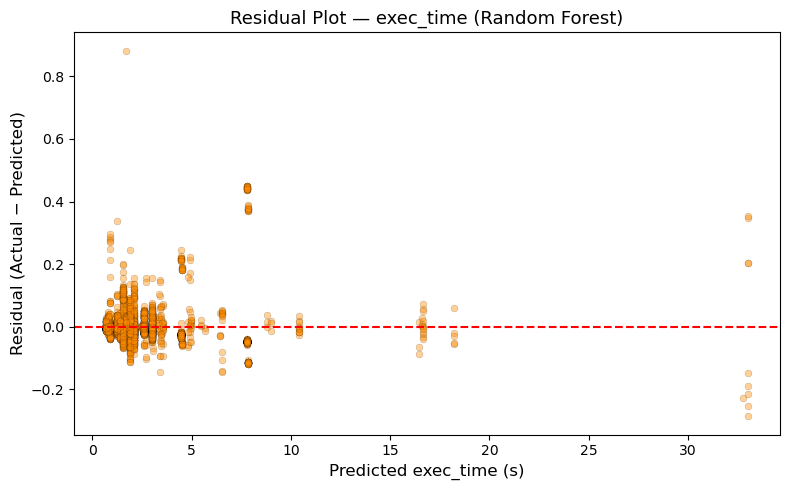

In [16]:
residuals = y_test.values - y_pred_rf

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_rf, residuals, alpha=0.4, color='darkorange',
            edgecolors='k', linewidths=0.2, s=25)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted exec_time (s)', fontsize=12)
plt.ylabel('Residual (Actual − Predicted)', fontsize=12)
plt.title('Residual Plot — exec_time (Random Forest)', fontsize=13)
plt.tight_layout()
plt.show()
plt.close()

### 12: Model Comparison Bar Chart (R² and RMSE)

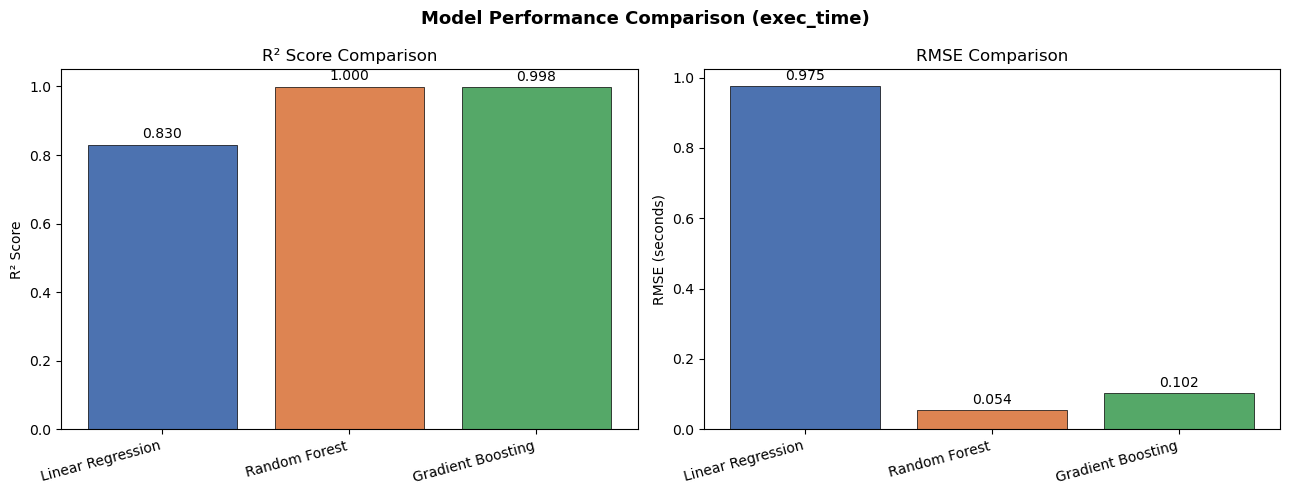

In [17]:
model_names = list(results.keys())
r2_vals   = [results[m]['R2']   for m in model_names]
rmse_vals = [results[m]['RMSE'] for m in model_names]
colors    = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# R² chart
bars = axes[0].bar(model_names, r2_vals, color=colors, edgecolor='k', linewidth=0.5)
axes[0].set_title('R² Score Comparison', fontsize=12)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# RMSE chart
bars2 = axes[1].bar(model_names, rmse_vals, color=colors, edgecolor='k', linewidth=0.5)
axes[1].set_title('RMSE Comparison', fontsize=12)
axes[1].set_ylabel('RMSE (seconds)')
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Performance Comparison (exec_time)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

### 13: exec_time Distribution by Workload Class

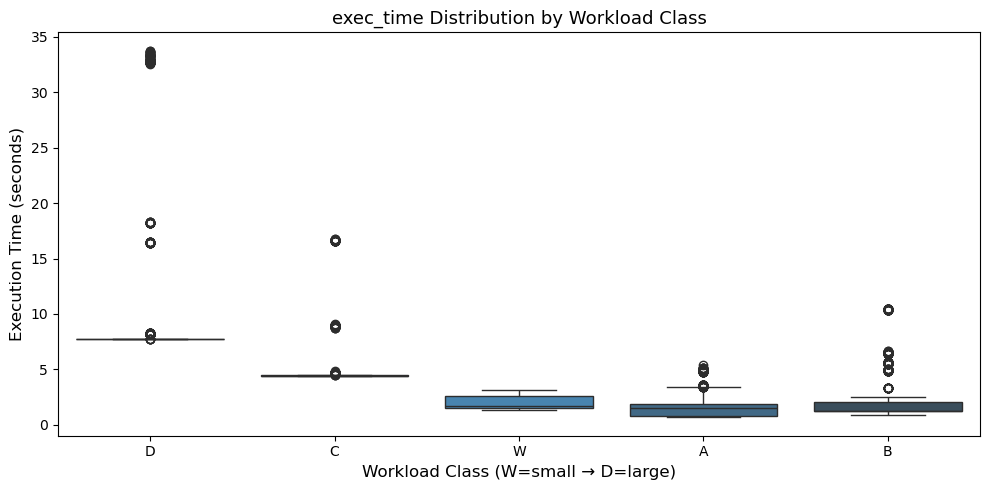

In [18]:
# Reload original for plotting (before encoding)
df_orig = pd.read_csv('cpu_d6515_07132020.csv')

plt.figure(figsize=(10, 5))
class_order = df_orig.groupby('class')['exec_time'].median().sort_values(ascending=False).index
sns.boxplot(data=df_orig, x='class', y='exec_time',
            order=class_order, palette='Blues_d')
plt.title('exec_time Distribution by Workload Class', fontsize=13)
plt.xlabel('Workload Class (W=small → D=large)', fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

### 14: Results Summary

In [20]:
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
results_df = pd.DataFrame(results).T
print(results_df.to_string())


RESULTS SUMMARY
                      MAE    RMSE      R2  CV_R2_mean  CV_R2_std
Linear Regression  0.3354  0.9748  0.8298      0.8138     0.0071
Random Forest      0.0256  0.0537  0.9995      0.9995     0.0002
Gradient Boosting  0.0449  0.1021  0.9981      0.9981     0.0004
